#  Titanic Survival Prediction

## CodSoft Data Science Internship - Task 1

###  Objective
The objective of this project is to build a Machine Learning model that predicts whether a passenger survived the Titanic disaster or not.

###  Dataset Features
- PassengerId
- Pclass
- Sex
- Age
- SibSp
- Parch
- Fare
- Embarked

###  Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

###  Machine Learning Algorithm
- Logistic Regression

###  Project Workflow
1. Data Loading
2. Data Cleaning
3. Data Visualization
4. Feature Engineering
5. Model Training
6. Prediction
7. Accuracy Evaluation

###  Expected Outcome
Predict passenger survival with good accuracy using Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info() 
df 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
df.isnull().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df = df[
    [
        'PassengerId',
        'Survived',
        'Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked'
    ]
]

In [10]:
# Convert Sex column into numbers

df['Sex'] = df['Sex'].replace({
    'male':0,
    'female':1
})

# Fill missing Age values

df['Age'] = df['Age'].fillna(df['Age'].mean())

# Fill missing Embarked values

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

# Convert Embarked column into numbers

df['Embarked'] = df['Embarked'].replace({
    'S':0,
    'C':1,
    'Q':2
})

# Remove remaining null values

df.dropna(inplace=True)

# Convert datatype

df['Sex'] = df['Sex'].astype(int)

df['Embarked'] = df['Embarked'].astype(int)

# Show cleaned data

df.head()

C:\Users\Win\AppData\Local\Temp\ipykernel_14324\4024089435.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].replace({
C:\Users\Win\AppData\Local\Temp\ipykernel_14324\4024089435.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df['Age'].fillna(df['Age'].mean())
C:\Users\Win\AppData\Local\Temp\ipykernel_14324\4024089435.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

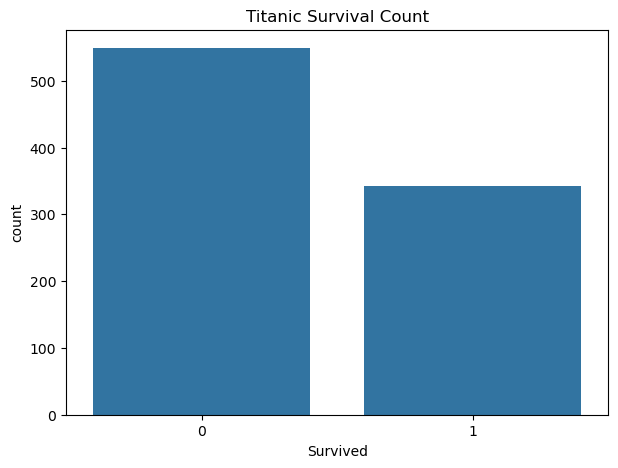

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(x='Survived', data=df)

plt.title("Titanic Survival Count")

plt.show()

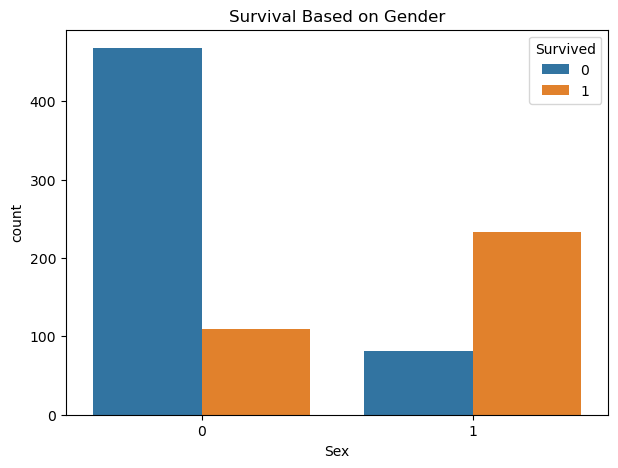

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival Based on Gender")

plt.show()

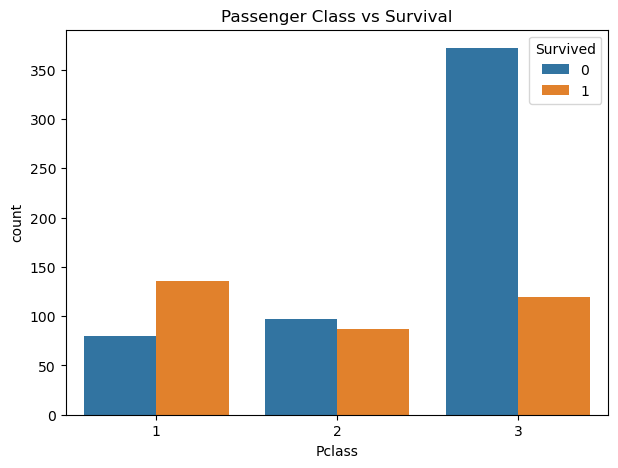

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Passenger Class vs Survival")

plt.show()

In [16]:
# Features

X = df.drop('Survived', axis=1)

# Target

y = df['Survived']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (712, 8)
Testing Shape: (179, 8)


In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
model = LogisticRegression(max_iter=1000)


In [20]:
model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [22]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
model = LogisticRegression(max_iter=1000)

In [26]:
model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [27]:
predictions = model.predict(X_test)

print(predictions)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


In [28]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7988826815642458


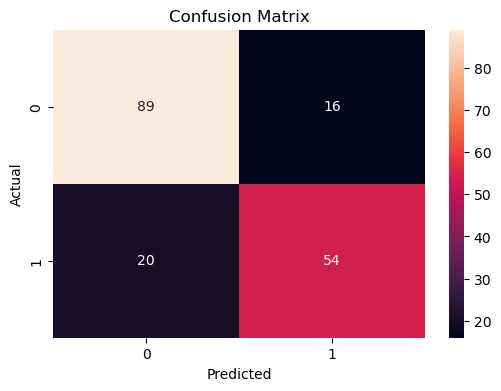

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [35]:
sample = pd.DataFrame(
    [[1, 3, 0, 22, 1, 0, 7.25, 0]],
    columns=[
        'PassengerId',
        'Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked'
    ]
)

result = model.predict(sample)

if result[0] == 1:
    print("✅ Passenger Survived")
else:
    print("❌ Passenger Did Not Survive")

❌ Passenger Did Not Survive


In [36]:
print("Titanic Survival Prediction Project Completed Successfully")

print("Final Accuracy:", accuracy)

print("Machine Learning Model Executed Successfully")

Titanic Survival Prediction Project Completed Successfully
Final Accuracy: 0.7988826815642458
Machine Learning Model Executed Successfully
